
# 10 - Model Fine Tuning

Este notebook realiza **fine tuning** del modelo usando el dataset:

`data/processed/training_dataset.parquet`

## Objetivo
Optimizar el desempeño del modelo de predicción de `produccion_kg` con una validación **temporal correcta**.

## Idea central
Antes del split y antes de cualquier validación:
- el dataset se **ordena por fecha**
- el conjunto de entrenamiento se define con fechas pasadas
- el conjunto de prueba se define con fechas futuras

Dentro del entrenamiento:
- se usa **TimeSeriesSplit**
- se ajustan hiperparámetros con búsqueda aleatoria
- se evalúa el mejor modelo en el bloque temporal de test

## Modelos incluidos
- ExtraTreesRegressor
- RandomForestRegressor
- HistGradientBoostingRegressor

## Nota importante
Este notebook asume que ya quitaste variables con leakage como:
- `ordenos_dia`
- `di_mean`
- `dd_mean`
- `ti_mean`
- `td_mean`

y que `produccion_roll_mean_3` fue calculada usando solo pasado.


## 1. Importaciones

In [27]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance



## 2. Carga del dataset

Se intenta primero la ruta pedida y luego algunas rutas alternativas comunes.


In [28]:

def resolve_path() -> Path:
    candidates = [
        Path("../data/processed/training_dataset.parquet"),
        Path("./data/processed/training_dataset.parquet"),
        Path("/mnt/data/data/processed/training_dataset.parquet"),
        Path("/mnt/data/training_dataset.parquet"),
        Path("./outputs/training_dataset.parquet"),
        Path("./outputs/dataset_ml_ready_cleaned.parquet"),
        Path("/mnt/data/dataset_ml_ready_cleaned.parquet"),
        Path("./training_dataset.parquet"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("No se encontró training_dataset.parquet en las rutas esperadas.")

DATA_PATH = resolve_path()
print("Dataset encontrado en:", DATA_PATH)

df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

print("Shape inicial:", df.shape)
display(df.head())


Dataset encontrado en: /Users/josemanuelromoperedo/Desktop/ProyectoGranja/data/processed/training_dataset.parquet
Shape inicial: (18345, 175)


,cow_id,date,ordenos_dia,produccion_kg,duracion_total_min,duracion_prom_min,intervalo_ordeno_prom_min,di_mean,dd_mean,td_mean,...,diet_kg_am_pm_maiz_molido,diet_kg_am_pm_melaza50pct_agua,diet_kg_am_pm_oro_balance,diet_kg_am_pm_oro_milk,diet_kg_am_pm_pasta_se_soya,diet_kg_am_pm_pata_de_cebada,diet_kg_am_pm_silo_de_avena,diet_kg_am_pm_silo_de_maiz,diet_kg_am_pm_triticale,has_event
0,1204,2022-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1204,2022-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1204,2022-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1204,2022-08-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1204,2022-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1



## 3. Limpieza mínima y orden temporal

### Decisión
El dataframe se ordena por `date` antes de construir el split temporal.

### Justificación
Si el split se hace sin ordenar, el train y el test pueden quedar mezclados temporalmente aunque la fecha de corte exista.


In [29]:

TARGET = "produccion_kg"

if TARGET not in df.columns:
    raise ValueError(f"No existe la columna target: {TARGET}")

df = df.dropna(subset=["date", TARGET]).copy()

# Orden temporal global
df = df.sort_values(["date", "cow_id"]).reset_index(drop=True)

print("Rango de fechas:", df["date"].min(), "->", df["date"].max())
print("Filas:", len(df))
print("Vacas únicas:", df["cow_id"].nunique() if "cow_id" in df.columns else "N/A")
display(df.head())


Rango de fechas: 2025-01-01 00:00:00 -> 2025-09-30 00:00:00
Filas: 9814
Vacas únicas: 65


,cow_id,date,ordenos_dia,produccion_kg,duracion_total_min,duracion_prom_min,intervalo_ordeno_prom_min,di_mean,dd_mean,td_mean,...,diet_kg_am_pm_maiz_molido,diet_kg_am_pm_melaza50pct_agua,diet_kg_am_pm_oro_balance,diet_kg_am_pm_oro_milk,diet_kg_am_pm_pasta_se_soya,diet_kg_am_pm_pata_de_cebada,diet_kg_am_pm_silo_de_avena,diet_kg_am_pm_silo_de_maiz,diet_kg_am_pm_triticale,has_event
0,1204,2025-01-01,1.0,16.68,11.216667,11.216667,1309.000000,5.160,4.640000,6.880,...,NaN,256.41,NaN,1213.52,NaN,35.42,NaN,NaN,1937.32,0
1,1213,2025-01-01,2.0,32.59,17.183333,8.591667,1027.500000,4.655,4.710000,5.120,...,NaN,256.41,NaN,1213.52,NaN,35.42,NaN,NaN,1937.32,0
2,1216,2025-01-01,2.0,29.09,10.433333,5.216667,665.500000,1.255,3.265000,4.685,...,NaN,256.41,NaN,1213.52,NaN,35.42,NaN,NaN,1937.32,0
3,1225,2025-01-01,2.0,10.35,23.466667,11.733333,531.500000,1.345,1.775000,0.610,...,NaN,256.41,NaN,1213.52,NaN,35.42,NaN,NaN,1937.32,0
4,1228,2025-01-01,3.0,43.55,27.000000,9.000000,478.666667,3.680,3.563333,3.890,...,NaN,256.41,NaN,1213.52,NaN,35.42,NaN,NaN,1937.32,0



## 4. Exclusión explícita de columnas con leakage o no aptas

### Decisión
Se eliminan:
- ids puros
- texto libre
- metadata
- columnas detectadas como leakage

### Justificación
Estas variables inflan artificialmente el desempeño o no generalizan.


In [30]:

drop_cols = [
    "date",                # se usa solo para split temporal
    #"cow_id",              # id puro, no generaliza
    "ms",
    "source_file",
    "raw_event_text",
    "event_types",
    "diagnosis_text",
    "medication_text",
    "treatment_text",
    "diagnosis_categories",
    "treatment_categories",
    "medication_categories",
    "THI_category",
    "date",
    "last_calving",
    "n_ingredientes",

    # columnas con leakage detectado
    "ordenos_dia",
    "di_mean",
    "dd_mean",
    "ti_mean",
    "td_mean",
    "duracion_total_min",  # proxy fuerte del target para predicción anticipada
    
    # Varaibles Autoregresivas (si se usan, deben usarse con cuidado y solo en modelos autoregresivos)
    "produccion_roll_mean_3",
    "produccion_lag_1",
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols, errors="ignore").copy()
y = df[TARGET].copy()

print("Shape X:", X.shape)
display(pd.DataFrame({
    "column": X.columns,
    "dtype": [str(X[c].dtype) for c in X.columns]
}).head(100))


Shape X: (9814, 155)


,column,dtype
0,cow_id,Int64
1,duracion_prom_min,float64
2,intervalo_ordeno_prom_min,float64
3,ubre,float64
4,destino_leche,str
...,...,...
95,consumo_prom_corral,float64
96,ratio_consumo_oferta_global,float64
97,ratio_sobrante_oferta_global,float64
98,ratio_rechazo_consumo_global,float64



## 5. Split temporal holdout

### Decisión
Se hace un split por fecha:
- 80% del horizonte temporal para entrenamiento
- 20% final para prueba

### Justificación
El test debe representar el futuro respecto al train.


In [31]:

unique_dates = np.array(sorted(df["date"].dropna().unique()))
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

# Orden temporal dentro de train/test
train_order = df.loc[train_mask, ["date"]].copy().sort_values("date").index
test_order = df.loc[test_mask, ["date"]].copy().sort_values("date").index

X_train = X_train.loc[train_order]
y_train = y_train.loc[train_order]

X_test = X_test.loc[test_order]
y_test = y_test.loc[test_order]

print("Split date:", split_date)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Split date: 2025-06-09 00:00:00
Train: (9207, 155) (9207,)
Test : (607, 155) (607,)



## 6. Preprocesamiento

### Estrategia
- Numéricas: imputación por mediana
- Categóricas: imputación por moda + one-hot encoding

No se usa escalado porque los modelos árbol no lo requieren.


In [32]:

numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numéricas:", len(numeric_cols))
print("Categóricas:", len(categorical_cols))
print("Primeras categóricas:", categorical_cols[:20])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


Numéricas: 153
Categóricas: 2
Primeras categóricas: ['destino_leche', 'diet_period']



## 7. Validación temporal interna

### Decisión
Se usa `TimeSeriesSplit` sobre el conjunto de entrenamiento.

### Justificación
Durante el tuning también debemos respetar la dirección temporal.


In [33]:

tscv = TimeSeriesSplit(n_splits=4)
print(tscv)


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None)



## 8. Definición de pipelines y espacios de búsqueda

Se eligen tres modelos de árboles porque manejan bien:
- no linealidades
- interacciones
- mezcla de variables densas y sparse


In [34]:

pipe_et = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1))
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

pipe_hgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

param_dist_et = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 8, 12, 16, 24],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
}

param_dist_rf = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 8, 12, 16, 24],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
}

param_dist_hgb = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [None, 4, 6, 8, 12],
    "model__max_iter": [200, 300, 500, 700],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0.0, 0.1, 1.0, 5.0],
}



## 9. Búsqueda aleatoria

### Decisión
Se usa `RandomizedSearchCV` en vez de grid search.

### Justificación
Permite explorar mejor el espacio con menos costo computacional.


In [35]:

searches = {
    "ExtraTrees": RandomizedSearchCV(
        estimator=pipe_et,
        param_distributions=param_dist_et,
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True,
    ),
    "RandomForest": RandomizedSearchCV(
        estimator=pipe_rf,
        param_distributions=param_dist_rf,
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True,
    ),
    "HistGradientBoosting": RandomizedSearchCV(
        estimator=pipe_hgb,
        param_distributions=param_dist_hgb,
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True,
    ),
}


## 10. Entrenamiento y comparación

In [36]:

results = []
best_estimators = {}

for name, search in searches.items():
    print("=" * 80)
    print(f"Fine tuning: {name}")
    print("=" * 80)

    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_

    pred = search.best_estimator_.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "best_cv_score_neg_mae": search.best_score_,
        "test_RMSE": rmse,
        "test_MAE": mae,
        "test_R2": r2,
        "best_params": search.best_params_,
    })

results_df = pd.DataFrame(results).sort_values("test_RMSE").reset_index(drop=True)
display(results_df[["model", "best_cv_score_neg_mae", "test_RMSE", "test_MAE", "test_R2"]])


Fine tuning: ExtraTrees
Fitting 4 folds for each of 20 candidates, totalling 80 fits


/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

Fine tuning: RandomForest
Fitting 4 folds for each of 20 candidates, totalling 80 fits


/Users/josemanuelromoperedo/Desktop/ProyectoGranja/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['rumia_min' 'days_in_milk' 'group_id' 'body_condition_score' 'weight_kg'
 'del_at_dryoff' 'gestant_insem_number' 'diet_kg_seca_maiz_molido'
 'diet_kg_seca_oro_balance' 'diet_kg_seca_pasta_se_soya'
 'diet_kg_seca_silo_de_avena' 'diet_kg_seca_silo_de_maiz'
 'diet_kg_humeda_maiz_molido' 'diet_kg_humeda_oro_balance'
 'diet_kg_humeda_pasta_se_soya' 'diet_kg_humeda_silo_de_avena'
 'diet_kg_humeda_silo_de_maiz' 'diet_pct_ms_maiz_molido'
 'diet_pct_ms_oro_balance' 'diet_pct_ms_pasta_se_soya'
 'diet_pct_ms_silo_de_avena' 'diet_pct_ms_silo_de_maiz'
 'diet_kg_am_pm_maiz_molido' 'diet_kg_am_pm_oro_balance'
 'diet_kg_am_pm_pasta_se_soya' 'diet_kg_am_pm_silo_de_avena'
 'diet_kg_am_pm_silo_de_maiz']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/josemanuelromoperedo/Desk

Fine tuning: HistGradientBoosting
Fitting 4 folds for each of 20 candidates, totalling 80 fits


,model,best_cv_score_neg_mae,test_RMSE,test_MAE,test_R2
0,HistGradientBoosting,-7.532109,9.778102,7.338963,0.210866
1,RandomForest,-7.678677,9.945162,7.458321,0.183671
2,ExtraTrees,-7.693770,10.104307,7.625400,0.157336


## 11. Visualización de métricas

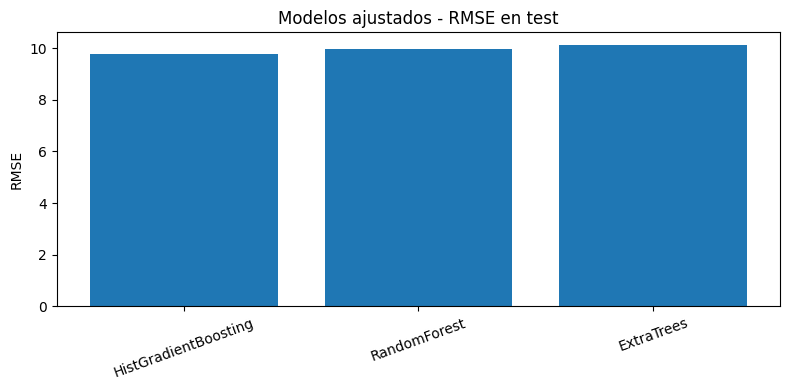

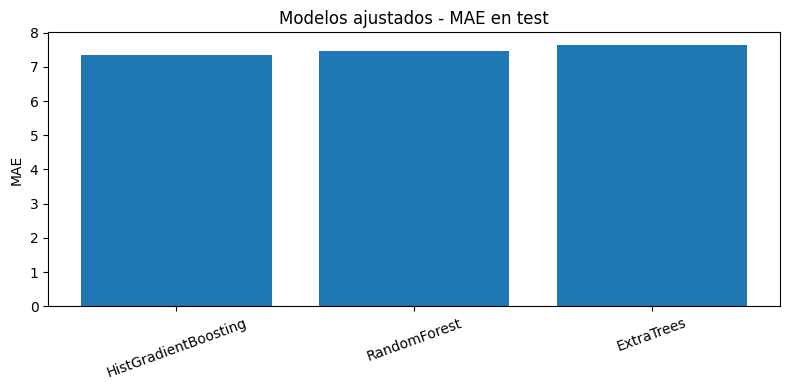

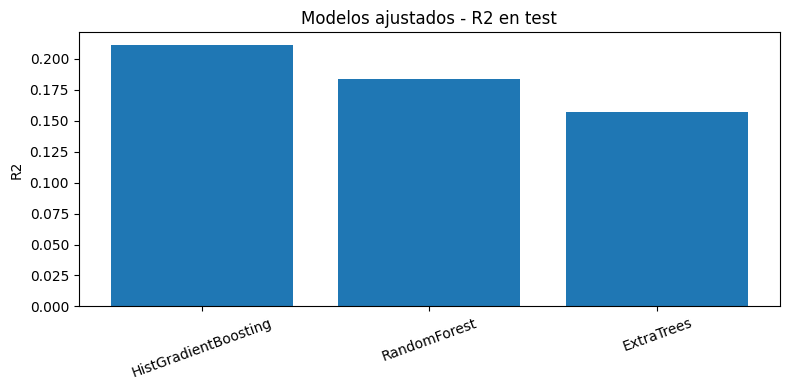

In [37]:

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_RMSE"])
plt.title("Modelos ajustados - RMSE en test")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_MAE"])
plt.title("Modelos ajustados - MAE en test")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_R2"])
plt.title("Modelos ajustados - R2 en test")
plt.ylabel("R2")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## 12. Mejor modelo final

Se selecciona el mejor por RMSE en test.


In [38]:

best_model_name = results_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]

best_pred = best_model.predict(X_test)

print("Mejor modelo:", best_model_name)
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("MAE :", mean_absolute_error(y_test, best_pred))
print("R2  :", r2_score(y_test, best_pred))
print("\nBest params:")
print(results_df.iloc[0]["best_params"])


Mejor modelo: HistGradientBoosting
RMSE: 9.778101557677626
MAE : 7.338962745642782
R2  : 0.21086614006766025

Best params:
{'model__min_samples_leaf': 30, 'model__max_iter': 200, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__l2_regularization': 1.0}


## 13. Predicción vs real

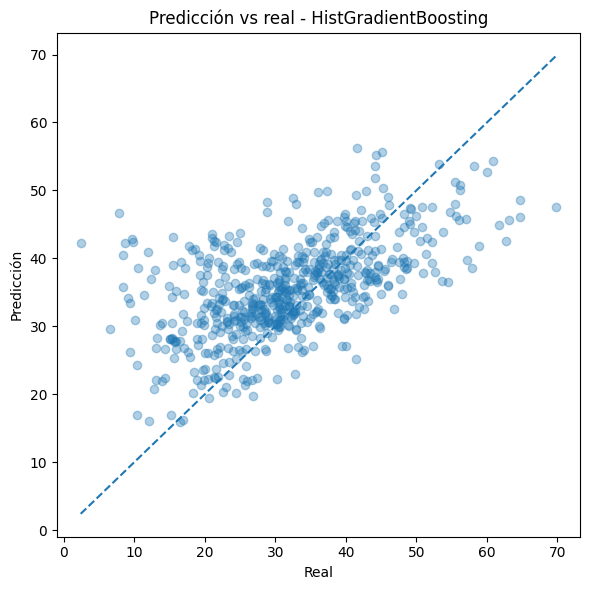

In [39]:

compare_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": best_pred
})

plt.figure(figsize=(6, 6))
plt.scatter(compare_df["y_true"], compare_df["y_pred"], alpha=0.35)
lims = [
    min(compare_df["y_true"].min(), compare_df["y_pred"].min()),
    max(compare_df["y_true"].max(), compare_df["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title(f"Predicción vs real - {best_model_name}")
plt.tight_layout()
plt.show()


In [40]:
MAE = mean_absolute_error(y_test, best_pred)
print("MAE:", MAE)

MAE: 7.338962745642782



## 14. Permutation importance del mejor modelo

Se usa `permutation_importance` sobre las columnas originales de `X_test`, no sobre las columnas transformadas.


,importance
cow_id,0.448114
intervalo_ordeno_prom_min,0.291116
duracion_prom_min,0.057032
destino_leche,0.026303
ubre,0.013527
relative_humidity_2m_mean,0.002551
antibiotic_flag,0.002213
ratio_consumo_oferta_global,0.001530
pressure_msl_mean,0.001340
kg_totales_total,0.001245


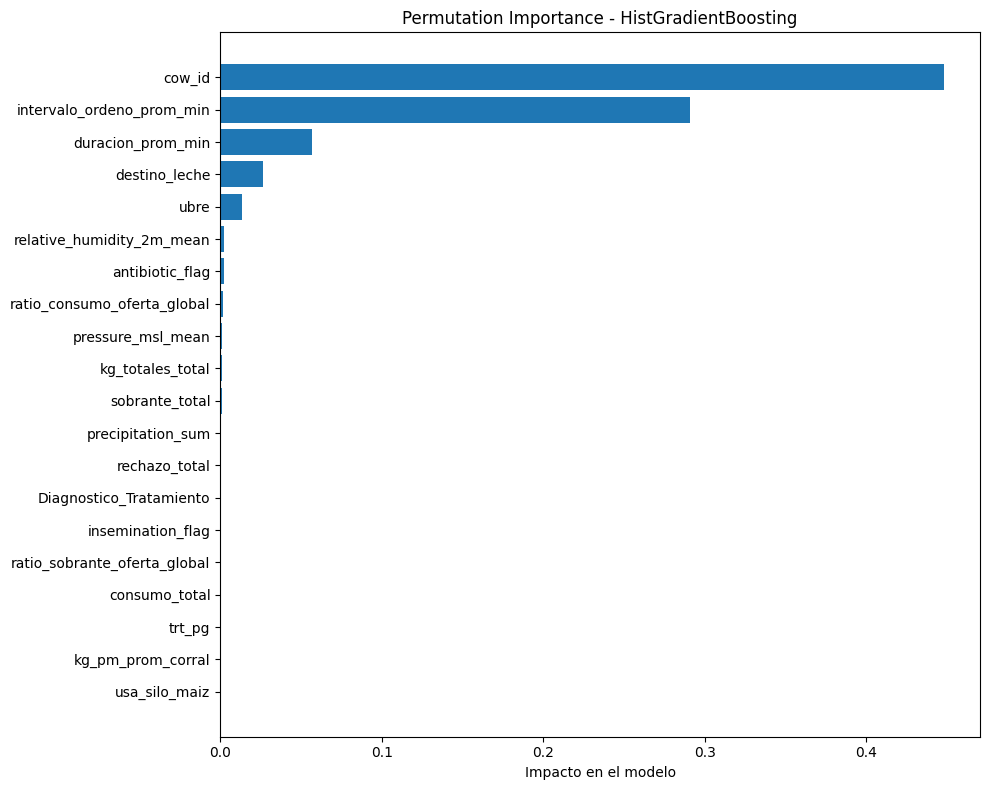

In [41]:

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

display(perm_importance.head(25).to_frame("importance"))

plt.figure(figsize=(10, 8))
top = perm_importance.head(20).sort_values()
plt.barh(top.index, top.values)
plt.title(f"Permutation Importance - {best_model_name}")
plt.xlabel("Impacto en el modelo")
plt.tight_layout()
plt.show()



## 15. Guardado de resultados

Se guardan:
- métricas de los modelos
- predicciones del mejor modelo
- importancias del mejor modelo


In [42]:

out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)

results_save = results_df.copy()
results_save["best_params"] = results_save["best_params"].astype(str)
results_save.to_csv(out_dir / "model_fine_tuning_results.csv", index=False)

pred_out = df.loc[test_mask, ["cow_id", "date", TARGET]].copy()
pred_out = pred_out.sort_values(["date", "cow_id"]).reset_index(drop=True)
pred_out["prediction"] = best_pred
pred_out.to_csv(out_dir / "best_finetuned_model_predictions.csv", index=False)

perm_importance.to_csv(out_dir / "best_finetuned_model_permutation_importance.csv", header=["importance"])

print("Guardado:")
print((out_dir / "model_fine_tuning_results.csv").resolve())
print((out_dir / "best_finetuned_model_predictions.csv").resolve())
print((out_dir / "best_finetuned_model_permutation_importance.csv").resolve())


Guardado:
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/model_fine_tuning_results.csv
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/best_finetuned_model_predictions.csv
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/best_finetuned_model_permutation_importance.csv



## 16. Conclusión

Este notebook busca una selección de hiperparámetros **honesta y temporalmente consistente**.

### Lo importante aquí
- ordenar por fecha antes del split
- usar validación temporal dentro del train
- excluir variables con leakage
- evaluar finalmente en un bloque futuro real
